# Détection du cancer du sein par apprentissage statistique


1. Régression Logistique ;
2. Naive Bayes ;
3. Ridge ;
4. Lasso ;
5. K-NN ;
6. MLP.


## 1. Installation et importation des librairies

In [1]:
# À exécuter une seule fois si les librairies ne sont pas installées :
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    matthews_corrcoef
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Chargement des données

La variable cible originale `Classification` est codée ainsi :

- `1` : témoin sain ;
- `2` : patiente atteinte de cancer.

Elle est recodée en format binaire :

- `0` : sain ;
- `1` : cancer.

In [2]:
# Chargement portable : le notebook cherche d'abord dans le dossier courant,
# puis dans /content/ pour Google Colab, puis dans /mnt/data/ pour cet environnement.
possible_paths = [
    Path("dataR2.csv"),
    Path("dataR2.xlsx"),
    Path("/content/dataR2.csv"),
    Path("/content/dataR2.xlsx"),
    Path("/mnt/data/dataR2.csv"),
    Path("/mnt/data/dataR2.xlsx"),
]
data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Fichier introuvable. Placez dataR2.csv ou dataR2.xlsx dans le même dossier que ce notebook, "
        "ou dans /content/ si vous utilisez Google Colab."
    )

if data_path.suffix.lower() == ".csv":
    df = pd.read_csv(data_path)
elif data_path.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(data_path)
else:
    raise ValueError("Format non supporté. Utilisez un fichier .csv ou .xlsx.")

print(f"Fichier chargé : {data_path}")

# Recodage de la cible : 1 -> 0, 2 -> 1
if set(df["Classification"].dropna().unique()) == {1, 2}:
    df["Classification"] = df["Classification"].map({1: 0, 2: 1})

features = [
    "Age", "BMI", "Glucose", "Insulin", "HOMA",
    "Leptin", "Adiponectin", "Resistin", "MCP.1"
]
target = "Classification"

# Vérification minimale de sécurité
missing_columns = [col for col in features + [target] if col not in df.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le fichier : {missing_columns}")

print("Aperçu des données :")
display(df.head())
print(f"Dimensions : {df.shape[0]} observations × {df.shape[1]} variables")
print("\nRépartition de la cible :")
display(df[target].value_counts().sort_index().rename(index={0: "Sain", 1: "Cancer"}).to_frame("Effectif"))

Fichier chargé : dataR2.xlsx
Aperçu des données :


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,0
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


Dimensions : 116 observations × 10 variables

Répartition de la cible :


,Effectif
Classification,
Sain,52
Cancer,64


## 3. Analyse exploratoire des données

In [3]:
print("Statistiques descriptives :")
display(df.describe().T.round(3))

print("\nValeurs manquantes par colonne :")
missing = df.isna().sum()
display(missing.to_frame("Valeurs manquantes"))

class_counts = df[target].value_counts().sort_index()
class_percent = (class_counts / len(df) * 100).round(2)
class_balance = pd.DataFrame({"Effectif": class_counts, "Pourcentage": class_percent})
class_balance.index = ["Sain", "Cancer"]
display(class_balance)

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
Age,116.0,57.302,16.113,24.000,45.000,56.000,71.000,89.000
BMI,116.0,27.582,5.020,18.370,22.973,27.662,31.241,38.579
Glucose,116.0,97.793,22.525,60.000,85.750,92.000,102.000,201.000
Insulin,116.0,10.012,10.068,2.432,4.359,5.924,11.189,58.460
HOMA,116.0,2.695,3.642,0.467,0.918,1.381,2.858,25.050
Leptin,116.0,26.615,19.183,4.311,12.314,20.271,37.378,90.280
Adiponectin,116.0,10.181,6.843,1.656,5.474,8.353,11.816,38.040
Resistin,116.0,14.726,12.391,3.210,6.882,10.828,17.755,82.100
MCP.1,116.0,534.647,345.913,45.843,269.978,471.322,700.085,1698.440
Classification,116.0,0.552,0.499,0.000,0.000,1.000,1.000,1.000



Valeurs manquantes par colonne :


,Valeurs manquantes
Age,0
BMI,0
Glucose,0
Insulin,0
HOMA,0
Leptin,0
Adiponectin,0
Resistin,0
MCP.1,0
Classification,0


,Effectif,Pourcentage
Sain,52,44.83
Cancer,64,55.17


**Interprétation.** Le dataset est de petite taille, avec 116 observations et 9 variables explicatives. La classe positive est légèrement majoritaire. Cette taille réduite impose d’être prudent : un seul découpage train/test peut donner une estimation instable des performances. C’est pourquoi la suite utilise une validation croisée répétée.

### 3.1 Matrice de corrélation

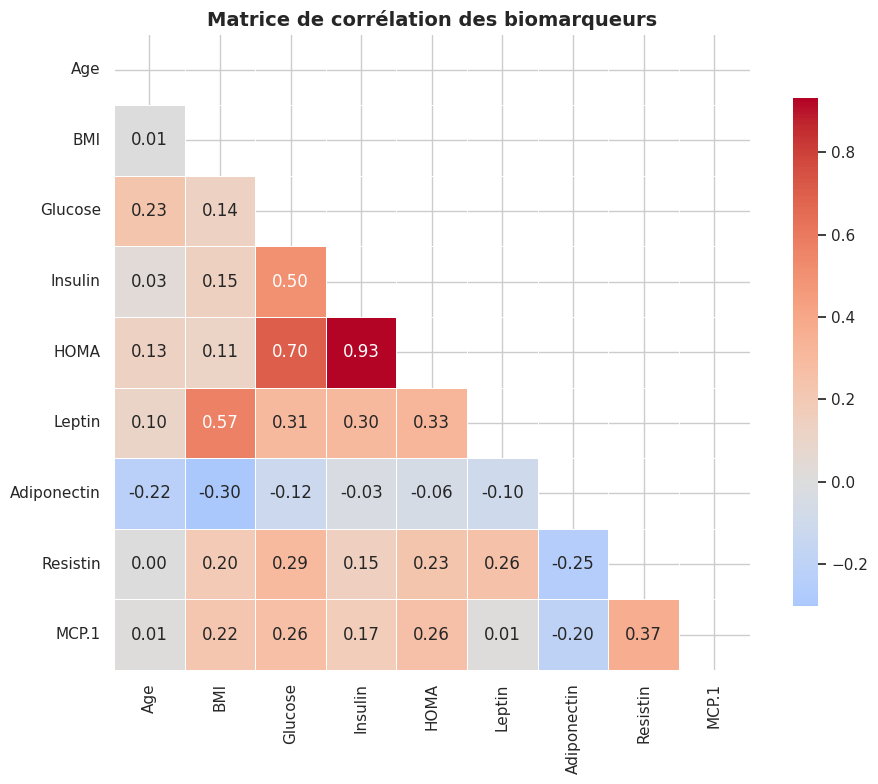

In [4]:
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de corrélation des biomarqueurs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interprétation.** La corrélation forte entre `Insulin` et `HOMA` est attendue, car HOMA est calculé à partir de l’insuline et du glucose. Cette colinéarité peut perturber l’interprétation directe des coefficients des modèles linéaires. Les modèles régularisés comme Ridge et Lasso permettent de mieux contrôler ce problème.

### 3.2 Distribution des variables principales par classe

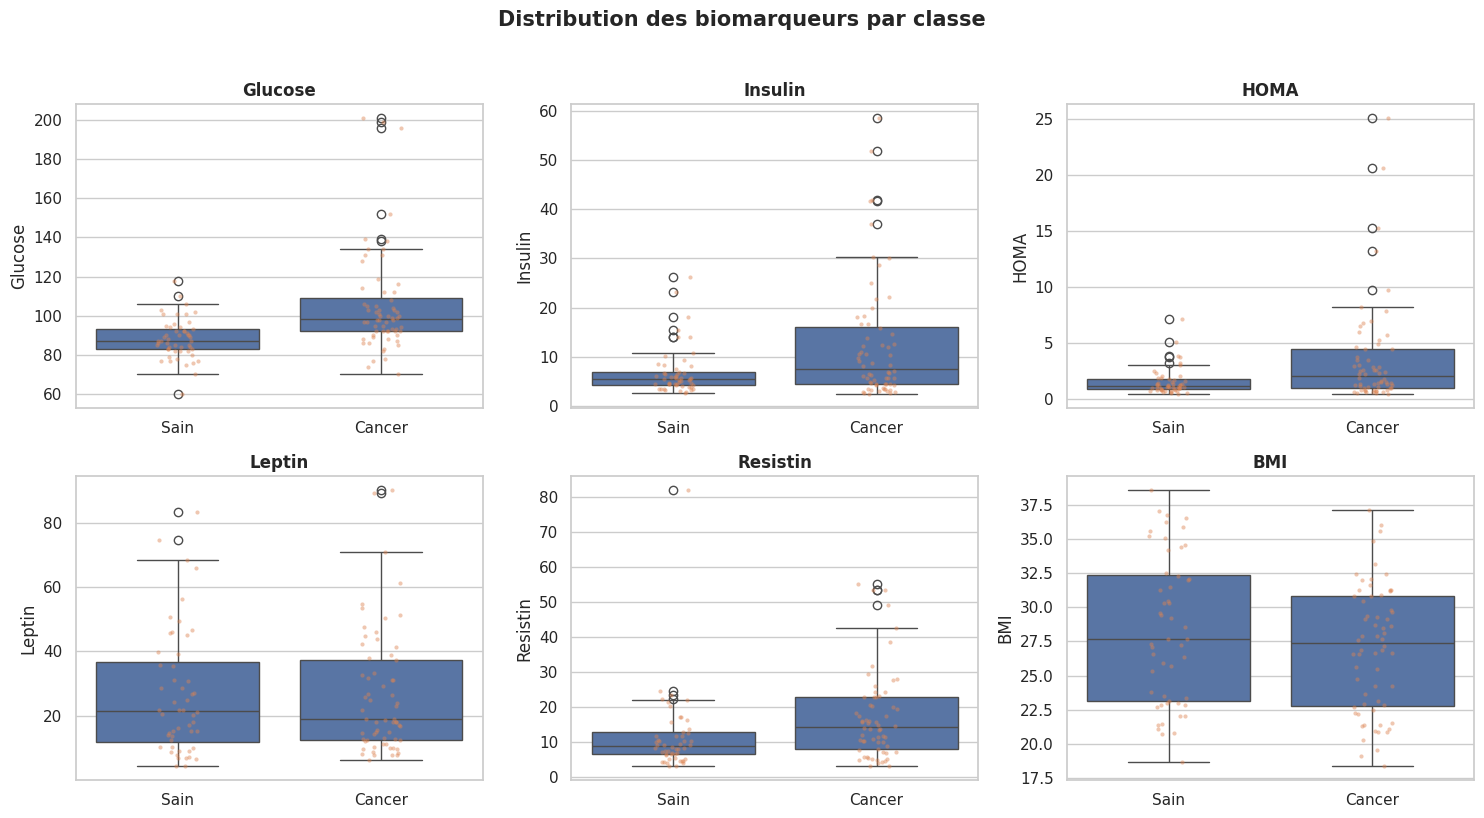

In [5]:
variables_cles = ["Glucose", "Insulin", "HOMA", "Leptin", "Resistin", "BMI"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, var in zip(axes, variables_cles):
    sns.boxplot(data=df, x=target, y=var, ax=ax)
    sns.stripplot(data=df, x=target, y=var, ax=ax, alpha=0.45, size=3)
    ax.set_xticklabels(["Sain", "Cancer"])
    ax.set_xlabel("")
    ax.set_title(var, fontweight="bold")

plt.suptitle("Distribution des biomarqueurs par classe", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots_biomarqueurs.png", dpi=150, bbox_inches="tight")
plt.show()

**Interprétation.** Certaines variables comme `Glucose`, `Resistin`, `Insulin` ou `HOMA` montrent des différences entre les deux groupes, mais les distributions restent chevauchées. Cela signifie qu’aucun biomarqueur seul ne permet une séparation parfaite entre les patientes saines et les patientes atteintes de cancer.

## 4. Préparation des données

La séparation train/test est stratifiée pour conserver la proportion des classes. La standardisation est intégrée dans les pipelines afin d’éviter les fuites de données pendant la validation croisée.

In [6]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")
print("\nRépartition dans le test :")
display(y_test.value_counts().sort_index().rename(index={0: "Sain", 1: "Cancer"}).to_frame("Effectif"))

Train : 92 observations
Test  : 24 observations

Répartition dans le test :


,Effectif
Classification,
Sain,11
Cancer,13


## 5. Baseline et modélisation détaillée des six modèles demandés

Cette section conserve les six modèles demandés :

1. Régression Logistique ;
2. Naive Bayes ;
3. Ridge ;
4. Lasso ;
5. K-NN ;
6. MLP.

La baseline `DummyClassifier` est conservée séparément : elle ne fait pas partie des six modèles principaux, mais elle sert de repère naïf.  
Pour chaque modèle principal, on présente maintenant :

- une cellule de code dédiée ;
- une optimisation par `GridSearchCV` avec validation croisée répétée ;
- un graphique interprétable propre au modèle.

La métrique d’optimisation utilisée est la `balanced_accuracy`, car elle tient compte à la fois de la sensibilité et de la spécificité.

In [7]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

best_models = {}
grid_objects = {}
cv_summary_rows = []


def register_grid_result(name, grid):
    """Sauvegarde le meilleur modèle et les résultats de validation croisée."""
    best_models[name] = grid.best_estimator_
    grid_objects[name] = grid
    cv_summary_rows.append({
        "Modèle": name,
        "Balanced accuracy CV": grid.best_score_,
        "Meilleurs paramètres": grid.best_params_
    })
    print(f"Meilleur score CV ({name}) : {grid.best_score_:.4f}")
    print(f"Meilleurs paramètres : {grid.best_params_}")


def extract_coef_vector(model_step):
    """Retourne correctement le vecteur de coefficients pour les modèles linéaires."""
    coefs = np.asarray(model_step.coef_)
    return coefs[0] if coefs.ndim > 1 else coefs


def plot_coefficients(model, title, filename):
    """Trace les coefficients standardisés d'un modèle linéaire."""
    model_step = model.named_steps["model"]
    coef_series = pd.Series(
        extract_coef_vector(model_step),
        index=features
    ).sort_values()

    display(coef_series.to_frame("Coefficient standardisé").round(4))

    ax = coef_series.plot(kind="barh", figsize=(8, 5))
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Coefficient standardisé")
    ax.axvline(0, linewidth=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_cv_by_parameter(grid, param_name, title, xlabel, filename):
    """Trace le meilleur score CV moyen selon un hyperparamètre."""
    cv_df = pd.DataFrame(grid.cv_results_)
    plot_df = (
        cv_df.groupby(f"param_{param_name}")["mean_test_score"]
        .max()
        .reset_index()
        .rename(columns={f"param_{param_name}": xlabel, "mean_test_score": "Balanced accuracy CV"})
    )
    plot_df[xlabel] = plot_df[xlabel].astype(str)
    display(plot_df.round(4))

    ax = plot_df.plot(x=xlabel, y="Balanced accuracy CV", kind="bar", figsize=(8, 4), legend=False)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Balanced accuracy CV")
    ax.set_xlabel(xlabel)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


### 5.A Étude technique : coût, optimisation et hyperparamètres

Avant d’entraîner les modèles un par un, on précise le fonctionnement technique de chaque approche. Cette partie répond aux éléments suivants : **fonction de coût**, **méthode d’optimisation** et **choix des hyperparamètres**.

La Régression Logistique et le MLP reposent sur une fonction de coût à minimiser. K-NN, au contraire, ne minimise pas une fonction de coût pendant l’apprentissage : sa décision dépend de la distance utilisée pour trouver les plus proches voisins.

In [8]:
# Tableau synthétique : fonction de coût, optimisation et hyperparamètres
etude_modeles = pd.DataFrame({
    "Modèle": [
        "Régression Logistique", "Naive Bayes", "RidgeClassifier",
        "Lasso", "K-NN", "MLP"
    ],
    "Fonction de coût / principe": [
        "Log-loss avec régularisation L2",
        "Estimation probabiliste conditionnelle",
        "Fonction linéaire régularisée L2",
        "Log-loss avec pénalisation L1",
        "Vote des plus proches voisins",
        "Log-loss du réseau de neurones"
    ],
    "Optimisation / décision": [
        "Solveur numérique lié au principe de descente de gradient",
        "Estimation statistique directe des probabilités",
        "Optimisation interne d'un modèle linéaire régularisé",
        "Optimisation numérique avec sélection de variables possible",
        "Pas d'apprentissage paramétrique ; décision par distance",
        "Backpropagation + Adam, variante adaptative de la descente de gradient"
    ],
    "Hyperparamètres étudiés": [
        "C",
        "var_smoothing",
        "alpha",
        "C",
        "n_neighbors, weights, metric (euclidean, manhattan)",
        "hidden_layer_sizes, alpha, learning_rate_init"
    ]
})

display(etude_modeles)


,Modèle,Fonction de coût / principe,Optimisation / décision,Hyperparamètres étudiés
0,Régression Logistique,Log-loss avec régularisation L2,Solveur numérique lié au principe de descente ...,C
1,Naive Bayes,Estimation probabiliste conditionnelle,Estimation statistique directe des probabilités,var_smoothing
2,RidgeClassifier,Fonction linéaire régularisée L2,Optimisation interne d'un modèle linéaire régu...,alpha
3,Lasso,Log-loss avec pénalisation L1,Optimisation numérique avec sélection de varia...,C
4,K-NN,Vote des plus proches voisins,Pas d'apprentissage paramétrique ; décision pa...,"n_neighbors, weights, metric (euclidean, manha..."
5,MLP,Log-loss du réseau de neurones,"Backpropagation + Adam, variante adaptative de...","hidden_layer_sizes, alpha, learning_rate_init"


### 5.0 Baseline DummyClassifier

La baseline prédit selon une règle naïve. Elle permet de vérifier que les modèles supervisés apprennent réellement mieux qu’une stratégie automatique.

In [9]:
# Baseline : modèle naïf de référence, non compté parmi les six modèles principaux.
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1]).ravel()
specificity_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) else 0

baseline_results = pd.DataFrame([{
    "Modèle": "Baseline DummyClassifier",
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_baseline),
    "Précision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "Recall / Sensibilité": recall_score(y_test, y_pred_baseline, zero_division=0),
    "Spécificité": specificity_b,
    "F1-score": f1_score(y_test, y_pred_baseline, zero_division=0),
    "FN": fn_b,
    "FP": fp_b
}]).set_index("Modèle")

display(baseline_results.round(4))


,Accuracy,Balanced Accuracy,Précision,Recall / Sensibilité,Spécificité,F1-score,FN,FP
Modèle,,,,,,,,
Baseline DummyClassifier,0.5417,0.5,0.5417,1.0,0.0,0.7027,0,11


### 5.1 Régression Logistique

La Régression Logistique est utilisée comme modèle linéaire de référence. Elle estime la probabilité d’appartenir à la classe `Cancer` à partir d’une combinaison linéaire des variables.

Sur le plan technique, ce modèle minimise une fonction de coût appelée **log-loss**. Cette minimisation peut être réalisée par des méthodes d’optimisation de type descente de gradient ou par des solveurs numériques plus optimisés. Dans notre notebook, l’implémentation `scikit-learn` utilise le solveur `lbfgs` avec une pénalisation L2.

Il ne faut donc pas considérer `SGD` comme un modèle supplémentaire ici : il s’agit plutôt d’un principe d’optimisation permettant de comprendre comment la log-loss peut être minimisée. L’hyperparamètre principal étudié est `C`, qui contrôle l’intensité de la régularisation.

Meilleur score CV (Régression Logistique) : 0.7604
Meilleurs paramètres : {'model__C': 1}


,Coefficient standardisé
Leptin,-0.4844
BMI,-0.4184
Age,-0.2701
Adiponectin,-0.0595
MCP.1,0.0514
HOMA,0.3120
Insulin,0.3145
Resistin,0.5514
Glucose,1.8631


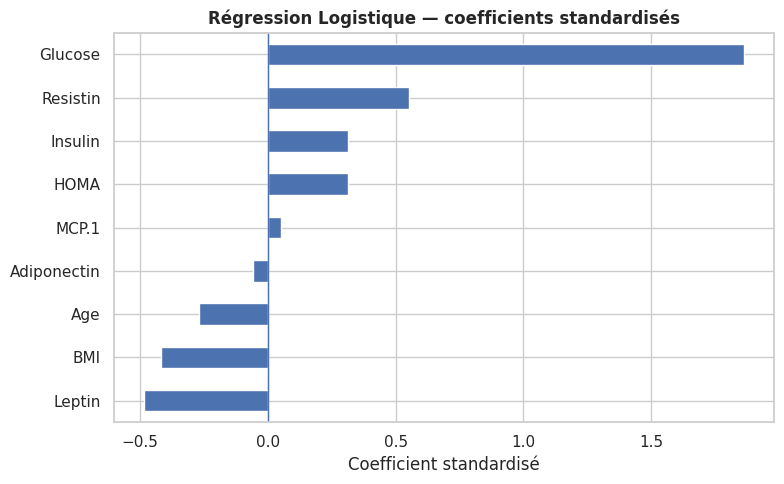

In [10]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logreg_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
logreg_grid.fit(X_train, y_train)
register_grid_result("Régression Logistique", logreg_grid)

plot_coefficients(
    logreg_grid.best_estimator_,
    "Régression Logistique — coefficients standardisés",
    "interpretation_regression_logistique_coefficients.png"
)


#### Remarque sur la descente de gradient

La descente de gradient consiste à ajuster progressivement les coefficients du modèle dans la direction qui réduit la fonction de coût. Pour la Régression Logistique, cette fonction de coût est la log-loss. Dans ce projet, on utilise le solveur optimisé de `scikit-learn`, mais l’idée mathématique reste celle d’une minimisation numérique de la perte.

### 5.2 Naive Bayes

Naive Bayes est un modèle probabiliste basé sur le théorème de Bayes. Il suppose que les variables sont indépendantes conditionnellement à la classe. Même si cette hypothèse est forte, le modèle est rapide et utile comme approche probabiliste simple sur un petit dataset.

Meilleur score CV (Naive Bayes) : 0.6517
Meilleurs paramètres : {'model__var_smoothing': np.float64(1e-12)}


,Moyenne standardisée Cancer - Sain
BMI,-0.2086
Leptin,-0.1006
Age,-0.0990
Adiponectin,-0.0579
MCP.1,0.1039
Resistin,0.4108
Insulin,0.5291
HOMA,0.5841
Glucose,0.8603


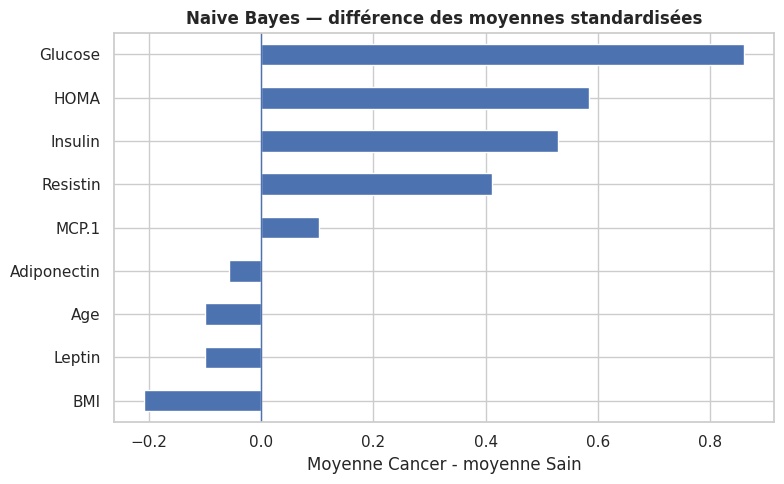

In [11]:
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

nb_params = {
    "model__var_smoothing": np.logspace(-12, -6, 7)
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
nb_grid.fit(X_train, y_train)
register_grid_result("Naive Bayes", nb_grid)

# Graphique interprétable : différence des moyennes standardisées entre Cancer et Sain.
nb_model = nb_grid.best_estimator_.named_steps["model"]
mean_sain = nb_model.theta_[0]
mean_cancer = nb_model.theta_[1]
mean_diff = pd.Series(mean_cancer - mean_sain, index=features).sort_values()

display(mean_diff.to_frame("Moyenne standardisée Cancer - Sain").round(4))

ax = mean_diff.plot(kind="barh", figsize=(8, 5))
ax.set_title("Naive Bayes — différence des moyennes standardisées", fontweight="bold")
ax.set_xlabel("Moyenne Cancer - moyenne Sain")
ax.axvline(0, linewidth=1)
plt.tight_layout()
plt.savefig("interpretation_naive_bayes_moyennes.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 RidgeClassifier

RidgeClassifier est un modèle linéaire régularisé par une pénalisation L2. Cette régularisation limite les coefficients trop élevés et rend le modèle plus stable, surtout en présence de corrélations entre variables, par exemple entre `Insulin` et `HOMA`.

Meilleur score CV (Ridge) : 0.7436
Meilleurs paramètres : {'model__alpha': np.float64(0.31622776601683794)}


,Coefficient standardisé
HOMA,-0.7285
BMI,-0.1675
Leptin,-0.1612
MCP.1,-0.0898
Age,-0.0682
Adiponectin,-0.0246
Resistin,0.1800
Glucose,0.6600
Insulin,0.7358


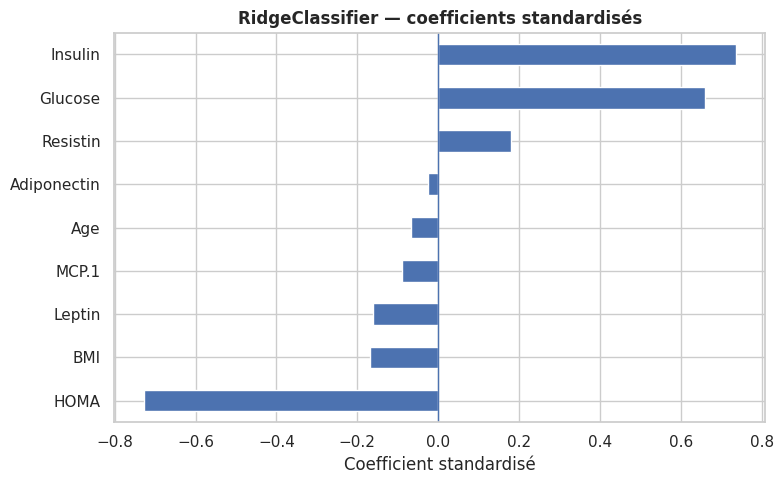

In [12]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])

ridge_params = {
    "model__alpha": np.logspace(-3, 3, 13)
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
ridge_grid.fit(X_train, y_train)
register_grid_result("Ridge", ridge_grid)

plot_coefficients(
    ridge_grid.best_estimator_,
    "RidgeClassifier — coefficients standardisés",
    "interpretation_ridge_coefficients.png"
)


### 5.4 Lasso

Le Lasso correspond ici à une Régression Logistique avec pénalisation L1. Cette pénalisation peut forcer certains coefficients à zéro, ce qui donne une forme de sélection automatique de variables. Le modèle est donc utile pour étudier quelles variables restent importantes après régularisation.

Meilleur score CV (Lasso) : 0.7546
Meilleurs paramètres : {'model__C': 1}
Variables retenues par Lasso : 6
Variables éliminées par Lasso : 3


,Coefficient standardisé
Leptin,-0.4931
BMI,-0.3288
Age,-0.2226
HOMA,0.0000
Adiponectin,0.0000
MCP.1,0.0000
Insulin,0.4060
Resistin,0.5067
Glucose,2.0506


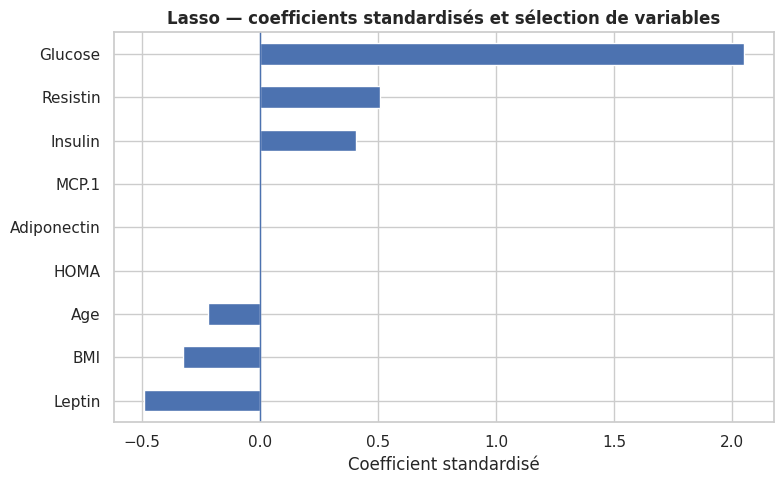

In [13]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

lasso_params = {
    "model__C": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
lasso_grid.fit(X_train, y_train)
register_grid_result("Lasso", lasso_grid)

lasso_model = lasso_grid.best_estimator_.named_steps["model"]
lasso_coefs = pd.Series(extract_coef_vector(lasso_model), index=features)
print(f"Variables retenues par Lasso : {(lasso_coefs != 0).sum()}")
print(f"Variables éliminées par Lasso : {(lasso_coefs == 0).sum()}")

plot_coefficients(
    lasso_grid.best_estimator_,
    "Lasso — coefficients standardisés et sélection de variables",
    "interpretation_lasso_coefficients.png"
)


### 5.5 K-NN

K-NN classe une nouvelle patiente à partir des observations les plus proches dans l’espace des biomarqueurs. Ce modèle peut capter des relations non linéaires, mais il dépend fortement de la notion de distance.

Dans ce projet, deux distances sont testées dans `GridSearchCV` :

- **Distance euclidienne** : distance directe entre deux observations ;
- **Distance de Manhattan** : somme des écarts absolus variable par variable.

Les formules sont :

\[
d_{euclidienne}(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
\]

\[
d_{manhattan}(x,y)=\sum_{i=1}^{n}|x_i-y_i|
\]

Comme K-NN est basé sur les distances, la standardisation des variables est indispensable afin qu’une variable avec une grande échelle ne domine pas le calcul de proximité.

Meilleur score CV (K-NN) : 0.7130
Meilleurs paramètres : {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}


,Nombre de voisins k,Balanced accuracy CV
0,3,0.6963
1,5,0.6931
2,7,0.7024
3,9,0.7029
4,11,0.7130
5,13,0.7110
6,15,0.6974


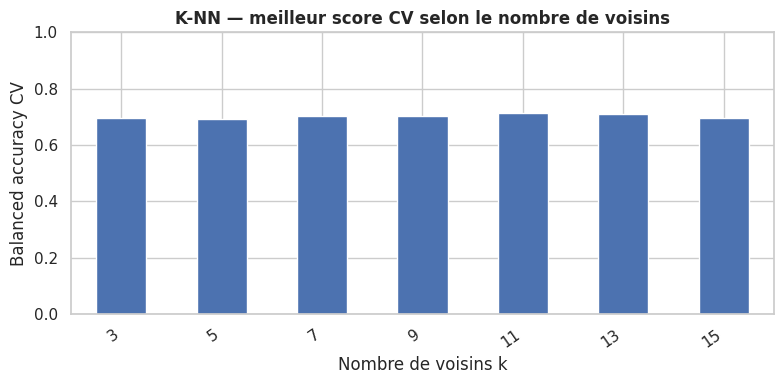

In [14]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
knn_grid.fit(X_train, y_train)
register_grid_result("K-NN", knn_grid)

plot_cv_by_parameter(
    knn_grid,
    "model__n_neighbors",
    "K-NN — meilleur score CV selon le nombre de voisins",
    "Nombre de voisins k",
    "interpretation_knn_cv_k.png"
)


#### Analyse spécifique de K-NN : impact de la distance

Le graphique suivant compare les scores moyens de validation croisée selon la distance utilisée. Il permet de voir si la distance euclidienne ou la distance de Manhattan donne les meilleurs résultats dans notre cas.

,Distance,Meilleur score CV
1,manhattan,0.713
0,euclidean,0.711


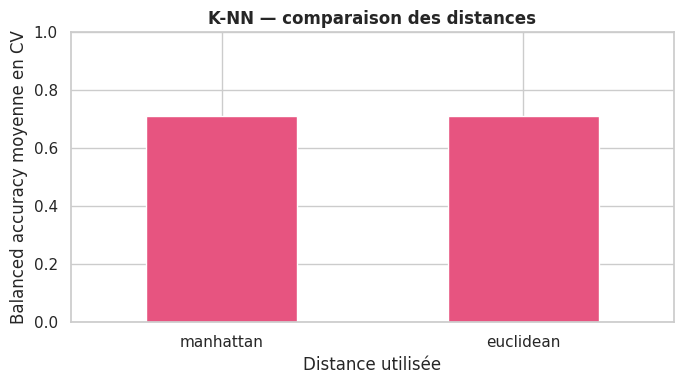

In [15]:
# Analyse interprétable de K-NN : effet de la distance utilisée
knn_cv_results = pd.DataFrame(knn_grid.cv_results_)

knn_distance_summary = (
    knn_cv_results
    .groupby("param_model__metric", as_index=False)["mean_test_score"]
    .max()
    .rename(columns={
        "param_model__metric": "Distance",
        "mean_test_score": "Meilleur score CV"
    })
    .sort_values("Meilleur score CV", ascending=False)
)

display(knn_distance_summary.round(4))

ax = knn_distance_summary.plot(
    kind="bar",
    x="Distance",
    y="Meilleur score CV",
    figsize=(7, 4),
    legend=False,
    color="#E75480"
)
ax.set_ylim(0, 1)
ax.set_title("K-NN — comparaison des distances", fontweight="bold")
ax.set_ylabel("Balanced accuracy moyenne en CV")
ax.set_xlabel("Distance utilisée")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("interpretation_knn_distance_metric.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.6 MLP

Le MLP est un réseau de neurones multicouche capable d’apprendre des relations non linéaires. Il est plus flexible que les modèles linéaires, mais il peut être plus sensible à la taille du dataset.

Sur le plan technique, le MLP minimise une fonction de coût de classification, ici une log-loss adaptée au réseau. Les poids du réseau sont ajustés par **rétropropagation**. L’optimisation repose sur une méthode de type descente de gradient ; dans notre notebook, le solveur utilisé est `adam`, une variante adaptative de la descente de gradient.

Les hyperparamètres étudiés concernent principalement la structure du réseau, la régularisation et le taux d’apprentissage.

Meilleur score CV (MLP) : 0.7367
Meilleurs paramètres : {'model__alpha': 0.001, 'model__hidden_layer_sizes': (32, 16), 'model__learning_rate_init': 0.01}


,Loss
46,0.031096
47,0.028505
48,0.026185
49,0.024024
50,0.022049


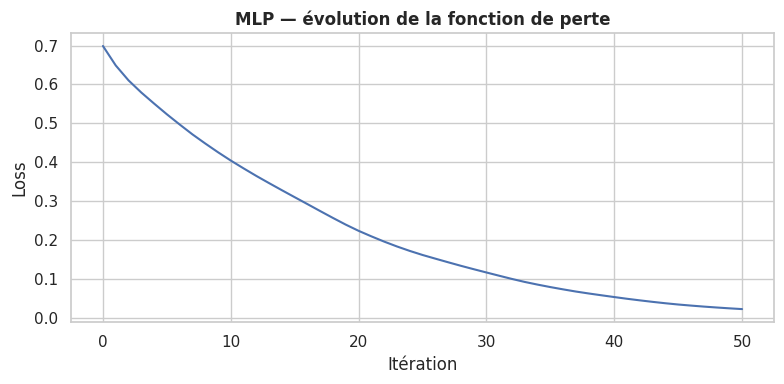

In [16]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=1500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE
    ))
])

mlp_params = {
    "model__hidden_layer_sizes": [(16,), (32,), (32, 16)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_params,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)
mlp_grid.fit(X_train, y_train)
register_grid_result("MLP", mlp_grid)

mlp_model = mlp_grid.best_estimator_.named_steps["model"]
if hasattr(mlp_model, "loss_curve_"):
    loss_series = pd.Series(mlp_model.loss_curve_, name="Loss")
    display(loss_series.tail().to_frame())

    ax = loss_series.plot(figsize=(8, 4))
    ax.set_title("MLP — évolution de la fonction de perte", fontweight="bold")
    ax.set_xlabel("Itération")
    ax.set_ylabel("Loss")
    plt.tight_layout()
    plt.savefig("interpretation_mlp_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("La courbe de perte n'est pas disponible pour ce modèle.")


#### Interprétation de la courbe de perte du MLP

La courbe de perte permet de suivre l’optimisation du réseau de neurones. Une perte qui diminue au fil des itérations indique que l’algorithme ajuste progressivement les poids du réseau. Dans notre cas, cette optimisation est réalisée par `adam`, une méthode issue de la descente de gradient adaptative.

### 5.7 Synthèse de la validation croisée

In [17]:
cv_summary = (
    pd.DataFrame(cv_summary_rows)
    .sort_values("Balanced accuracy CV", ascending=False)
    .reset_index(drop=True)
)
cv_summary.index = cv_summary.index + 1
cv_summary.index.name = "Rang CV"

display(cv_summary)
cv_summary.to_csv("resume_validation_croisee_6_modeles.csv", index=True)
print("Tableau sauvegardé : resume_validation_croisee_6_modeles.csv")


,Modèle,Balanced accuracy CV,Meilleurs paramètres
Rang CV,,,
1,Régression Logistique,0.760404,{'model__C': 1}
2,Lasso,0.754641,{'model__C': 1}
3,Ridge,0.743641,{'model__alpha': 0.31622776601683794}
4,MLP,0.736737,"{'model__alpha': 0.001, 'model__hidden_layer_s..."
5,K-NN,0.712955,"{'model__metric': 'manhattan', 'model__n_neigh..."
6,Naive Bayes,0.651677,{'model__var_smoothing': 1e-12}


Tableau sauvegardé : resume_validation_croisee_6_modeles.csv


**Interprétation.** Chaque modèle a été entraîné dans sa propre cellule avec une recherche d’hyperparamètres par `GridSearchCV`. Cette organisation rend la modélisation plus lisible : on peut voir séparément le rôle de chaque modèle, ses meilleurs paramètres et un graphique qui aide à interpréter son comportement. La validation croisée répétée donne une estimation plus stable que le simple jeu de test, mais les résultats restent prudents à cause de la petite taille du dataset.

## 6. Évaluation sur le jeu de test

In [18]:
def get_positive_scores(model, X_data):
    """Retourne un score continu pour calculer l'AUC.
    - predict_proba pour les modèles probabilistes ;
    - decision_function pour RidgeClassifier ;
    - prédiction binaire si aucun score continu n'est disponible.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    return model.predict(X_data)

models = best_models
rows = []
preds = {}
probas = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_score = get_positive_scores(model, X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    auc = roc_auc_score(y_test, y_score) if len(np.unique(y_score)) > 1 else np.nan

    # Score de synthèse adapté au dépistage : priorité au recall, mais sans ignorer la spécificité.
    medical_score = (
        0.40 * recall_score(y_test, y_pred, zero_division=0)
        + 0.30 * specificity
        + 0.20 * f1_score(y_test, y_pred, zero_division=0)
        + 0.10 * (auc if not np.isnan(auc) else 0)
    )

    rows.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred, zero_division=0),
        "Recall / Sensibilité": recall_score(y_test, y_pred, zero_division=0),
        "Spécificité": specificity,
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": auc,
        "MCC": matthews_corrcoef(y_test, y_pred),
        "FN": fn,
        "FP": fp,
        "Score médical pondéré": medical_score
    })
    preds[name] = y_pred
    probas[name] = y_score

results = pd.DataFrame(rows).set_index("Modèle").sort_values("Score médical pondéré", ascending=False)
display(results.round(4))

print("Comparaison avec la baseline :")
display(baseline_results.round(4))

results.to_csv("resultats_6_modeles_cancer_sein.csv", index=True)
baseline_results.to_csv("baseline_dummy_cancer_sein.csv", index=True)
print("Tableaux sauvegardés : resultats_6_modeles_cancer_sein.csv et baseline_dummy_cancer_sein.csv")

best_model_name = results.index[0]
best_model = models[best_model_name]
print(f"\nMeilleur compromis selon le score médical pondéré : {best_model_name}")

,Accuracy,Balanced Accuracy,Précision,Recall / Sensibilité,Spécificité,F1-score,AUC-ROC,MCC,FN,FP,Score médical pondéré
Modèle,,,,,,,,,,,
K-NN,0.7917,0.7937,0.8333,0.7692,0.8182,0.8000,0.7937,0.5854,3,2,0.7925
Régression Logistique,0.7083,0.7168,0.8000,0.6154,0.8182,0.6957,0.7762,0.4382,5,2,0.7084
MLP,0.7083,0.7168,0.8000,0.6154,0.8182,0.6957,0.7692,0.4382,5,2,0.7077
Lasso,0.7083,0.7168,0.8000,0.6154,0.8182,0.6957,0.7622,0.4382,5,2,0.7070
Naive Bayes,0.6667,0.6853,0.8571,0.4615,0.9091,0.6000,0.8671,0.4063,7,1,0.6641
Ridge,0.6667,0.6783,0.7778,0.5385,0.8182,0.6364,0.7133,0.3671,6,2,0.6594


Comparaison avec la baseline :


,Accuracy,Balanced Accuracy,Précision,Recall / Sensibilité,Spécificité,F1-score,FN,FP
Modèle,,,,,,,,
Baseline DummyClassifier,0.5417,0.5,0.5417,1.0,0.0,0.7027,0,11


Tableaux sauvegardés : resultats_6_modeles_cancer_sein.csv et baseline_dummy_cancer_sein.csv

Meilleur compromis selon le score médical pondéré : K-NN


**Interprétation.** Le tableau principal compare uniquement les six modèles demandés. La baseline est affichée séparément, car elle sert seulement de référence. Un modèle est réellement intéressant s’il dépasse clairement cette baseline tout en gardant un bon équilibre entre sensibilité et spécificité.

### 6.1 Rapports de classification

In [19]:
for name, model in models.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(classification_report(y_test, preds[name], target_names=["Sain", "Cancer"], zero_division=0))


Régression Logistique
              precision    recall  f1-score   support

        Sain       0.64      0.82      0.72        11
      Cancer       0.80      0.62      0.70        13

    accuracy                           0.71        24
   macro avg       0.72      0.72      0.71        24
weighted avg       0.73      0.71      0.71        24


Naive Bayes
              precision    recall  f1-score   support

        Sain       0.59      0.91      0.71        11
      Cancer       0.86      0.46      0.60        13

    accuracy                           0.67        24
   macro avg       0.72      0.69      0.66        24
weighted avg       0.73      0.67      0.65        24


Ridge
              precision    recall  f1-score   support

        Sain       0.60      0.82      0.69        11
      Cancer       0.78      0.54      0.64        13

    accuracy                           0.67        24
   macro avg       0.69      0.68      0.66        24
weighted avg       0.70      0.

### 6.2 Matrices de confusion

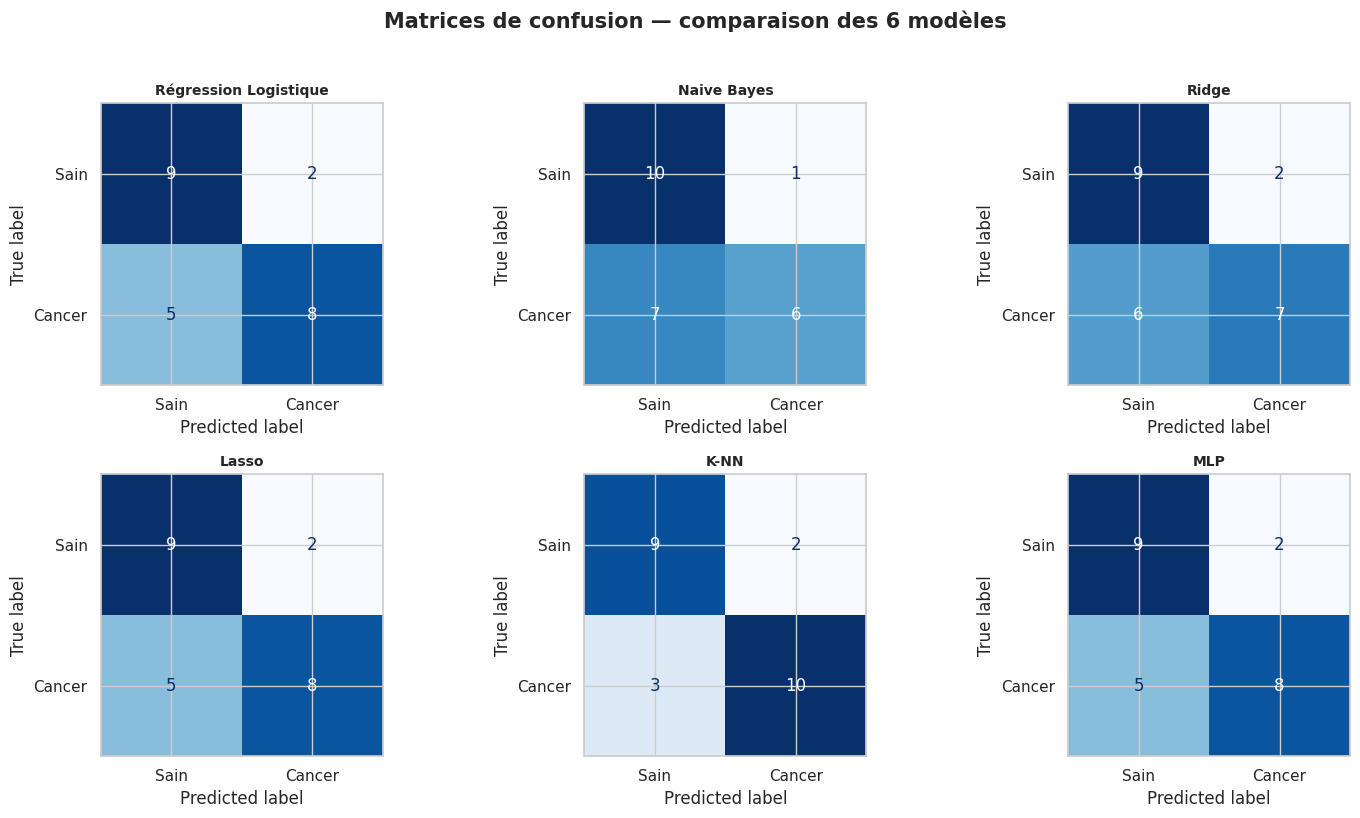

In [20]:
n_models = len(models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).ravel()

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds[name], labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Sain", "Cancer"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10, fontweight="bold")

for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Matrices de confusion — comparaison des 6 modèles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("matrices_confusion_6_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Courbes ROC

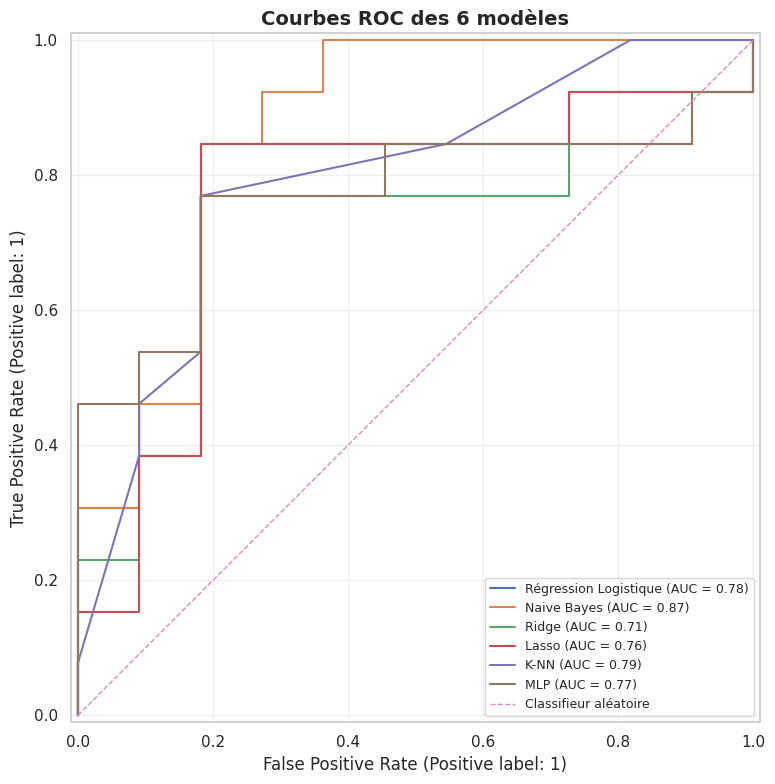

In [21]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, model in models.items():
    try:
        RocCurveDisplay.from_predictions(y_test, probas[name], name=name, ax=ax)
    except ValueError:
        pass

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Classifieur aléatoire")
ax.set_title("Courbes ROC des 6 modèles", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("courbes_roc_6_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.4 Comparaison graphique des métriques

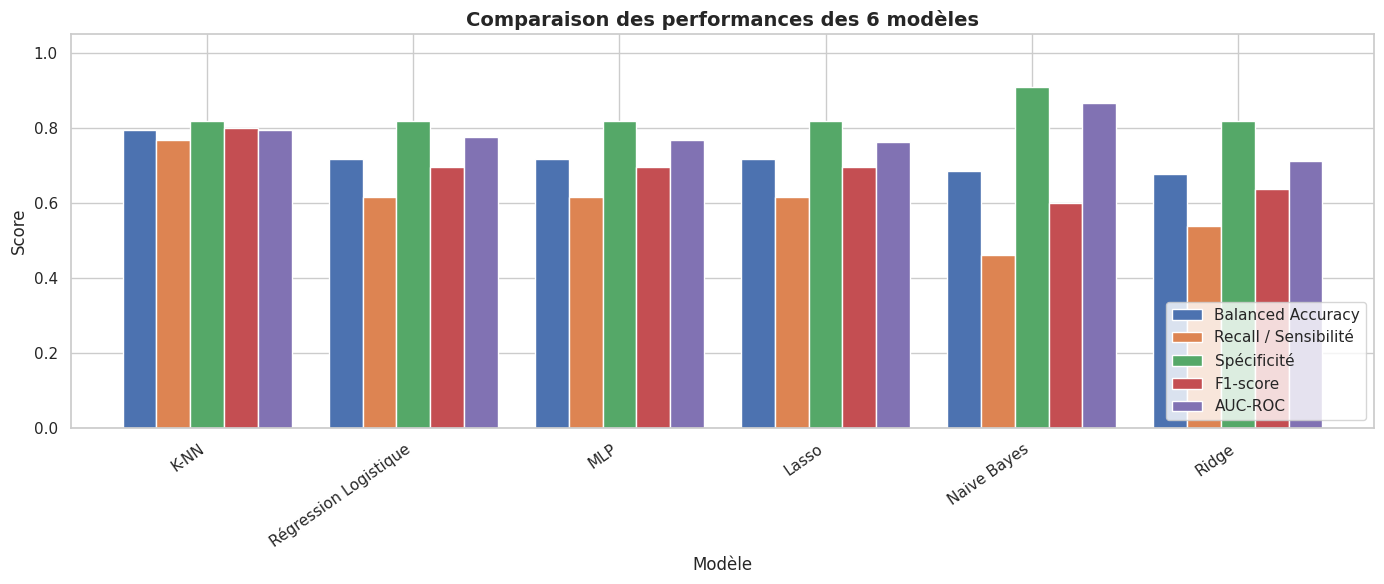

In [22]:
metrics_to_plot = ["Balanced Accuracy", "Recall / Sensibilité", "Spécificité", "F1-score", "AUC-ROC"]
plot_df = results[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparaison des performances des 6 modèles", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("comparaison_metriques_6_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.5 Comparaison approfondie des modèles

La comparaison ne doit pas être faite uniquement à partir de l'accuracy. Dans un contexte médical, il faut aussi prendre en compte :

- le **recall / sensibilité**, car il mesure la capacité à détecter les cas de cancer ;
- la **spécificité**, car elle mesure la capacité à reconnaître les patientes saines ;
- le **F1-score**, qui équilibre précision et recall ;
- l'**AUC-ROC**, qui mesure la séparation globale entre les deux classes ;
- les **faux négatifs (FN)**, particulièrement importants car ils correspondent à des cas de cancer non détectés ;
- les **faux positifs (FP)**, qui peuvent entraîner des examens inutiles et de l'anxiété.

Le classement final utilisé dans ce notebook repose sur un **score médical pondéré**. Ce score donne plus de poids à la sensibilité, sans négliger la spécificité, le F1-score et l'AUC-ROC.

,Rang,Accuracy,Balanced Accuracy,Recall / Sensibilité,Spécificité,F1-score,AUC-ROC,FN,FP,Score médical pondéré
Modèle,,,,,,,,,,
K-NN,1,0.7917,0.7937,0.7692,0.8182,0.8000,0.7937,3,2,0.7925
Régression Logistique,2,0.7083,0.7168,0.6154,0.8182,0.6957,0.7762,5,2,0.7084
MLP,3,0.7083,0.7168,0.6154,0.8182,0.6957,0.7692,5,2,0.7077
Lasso,4,0.7083,0.7168,0.6154,0.8182,0.6957,0.7622,5,2,0.7070
Naive Bayes,5,0.6667,0.6853,0.4615,0.9091,0.6000,0.8671,7,1,0.6641
Ridge,6,0.6667,0.6783,0.5385,0.8182,0.6364,0.7133,6,2,0.6594


Classement automatique selon le score médical pondéré :
1. K-NN | Score médical=0.7925 | Recall=0.7692 | Spécificité=0.8182 | FN=3 | FP=2
2. Régression Logistique | Score médical=0.7084 | Recall=0.6154 | Spécificité=0.8182 | FN=5 | FP=2
3. MLP | Score médical=0.7077 | Recall=0.6154 | Spécificité=0.8182 | FN=5 | FP=2
4. Lasso | Score médical=0.7070 | Recall=0.6154 | Spécificité=0.8182 | FN=5 | FP=2
5. Naive Bayes | Score médical=0.6641 | Recall=0.4615 | Spécificité=0.9091 | FN=7 | FP=1
6. Ridge | Score médical=0.6594 | Recall=0.5385 | Spécificité=0.8182 | FN=6 | FP=2


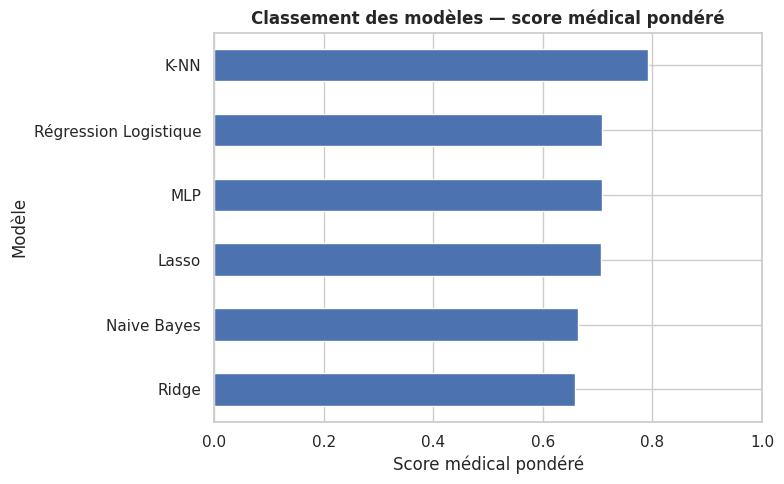

In [23]:
comparison_columns = [
    "Accuracy", "Balanced Accuracy", "Recall / Sensibilité",
    "Spécificité", "F1-score", "AUC-ROC", "FN", "FP", "Score médical pondéré"
]

ranking_table = results[comparison_columns].copy()
ranking_table.insert(0, "Rang", range(1, len(ranking_table) + 1))

display(ranking_table.round(4))

print("Classement automatique selon le score médical pondéré :")
for rank, (model_name, row) in enumerate(results.iterrows(), start=1):
    print(
        f"{rank}. {model_name} | "
        f"Score médical={row['Score médical pondéré']:.4f} | "
        f"Recall={row['Recall / Sensibilité']:.4f} | "
        f"Spécificité={row['Spécificité']:.4f} | "
        f"FN={int(row['FN'])} | FP={int(row['FP'])}"
    )

# Graphique synthétique : classement selon le score médical pondéré.
ax = results["Score médical pondéré"].sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_xlim(0, 1)
ax.set_title("Classement des modèles — score médical pondéré", fontweight="bold")
ax.set_xlabel("Score médical pondéré")
plt.tight_layout()
plt.savefig("classement_score_medical_pondere.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation développée.** Le meilleur modèle est celui qui offre le compromis le plus acceptable pour un problème de dépistage. Un modèle qui détecte tous les cancers mais classe presque toutes les patientes saines comme positives n'est pas satisfaisant. À l'inverse, un modèle très spécifique mais avec trop de faux négatifs est risqué médicalement. Le score médical pondéré permet donc de privilégier les modèles capables de réduire les faux négatifs tout en conservant une spécificité raisonnable. Le classement final doit toutefois être interprété avec prudence, car le jeu de test est petit et quelques erreurs peuvent modifier sensiblement les métriques.

## 7. Analyse du seuil de décision du meilleur modèle

Par défaut, un modèle classe une observation comme `Cancer` si la probabilité prédite est supérieure ou égale à 0,5. En contexte médical, on peut ajuster ce seuil pour réduire les faux négatifs. Cette analyse est informative : dans un vrai projet, le seuil doit être choisi sur un jeu de validation séparé.

In [24]:
y_score_best = get_positive_scores(best_model, X_test)
thresholds = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for threshold in thresholds:
    y_pred_thr = (y_score_best >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    threshold_rows.append({
        "Seuil": threshold,
        "Recall / Sensibilité": recall_score(y_test, y_pred_thr, zero_division=0),
        "Spécificité": specificity,
        "F1-score": f1_score(y_test, y_pred_thr, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_thr),
        "FN": fn,
        "FP": fp
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

threshold_table.to_csv("analyse_seuil_meilleur_modele.csv", index=False)
print("Tableau sauvegardé : analyse_seuil_meilleur_modele.csv")

,Seuil,Recall / Sensibilité,Spécificité,F1-score,Balanced Accuracy,FN,FP
0,0.20,1.000,0.000,0.703,0.500,0,11
1,0.25,1.000,0.000,0.703,0.500,0,11
2,0.30,1.000,0.182,0.743,0.591,0,9
3,0.35,1.000,0.182,0.743,0.591,0,9
4,0.40,0.846,0.455,0.733,0.650,2,6
5,0.45,0.846,0.455,0.733,0.650,2,6
6,0.50,0.769,0.818,0.800,0.794,3,2
7,0.55,0.538,0.818,0.636,0.678,6,2
8,0.60,0.538,0.818,0.636,0.678,6,2
9,0.65,0.462,0.909,0.600,0.685,7,1


Tableau sauvegardé : analyse_seuil_meilleur_modele.csv


**Interprétation.** Un seuil plus bas augmente généralement la sensibilité et diminue les faux négatifs, mais augmente les faux positifs. Un seuil plus haut fait l’inverse. Le choix dépend donc de l’objectif : dépistage précoce très sensible ou classification plus spécifique.

## 8. Interprétation globale des variables

Les graphiques spécifiques aux modèles linéaires ont déjà été intégrés dans la partie modélisation. Cette section regroupe les coefficients des modèles linéaires afin de comparer les variables les plus influentes selon la Régression Logistique, Ridge et Lasso. Pour Lasso, les coefficients nuls indiquent les variables éliminées par la régularisation L1.


Régression Logistique


,Coefficient standardisé
Glucose,1.8631
Resistin,0.5514
Leptin,-0.4844
BMI,-0.4184
Insulin,0.3145
HOMA,0.3120
Age,-0.2701
Adiponectin,-0.0595
MCP.1,0.0514



Ridge


,Coefficient standardisé
Insulin,0.7358
HOMA,-0.7285
Glucose,0.6600
Resistin,0.1800
BMI,-0.1675
Leptin,-0.1612
MCP.1,-0.0898
Age,-0.0682
Adiponectin,-0.0246



Lasso


,Coefficient standardisé
Glucose,2.0506
Resistin,0.5067
Leptin,-0.4931
Insulin,0.4060
BMI,-0.3288
Age,-0.2226
HOMA,0.0000
Adiponectin,0.0000
MCP.1,0.0000


Variables retenues par Lasso : 6
Variables éliminées par Lasso : 3


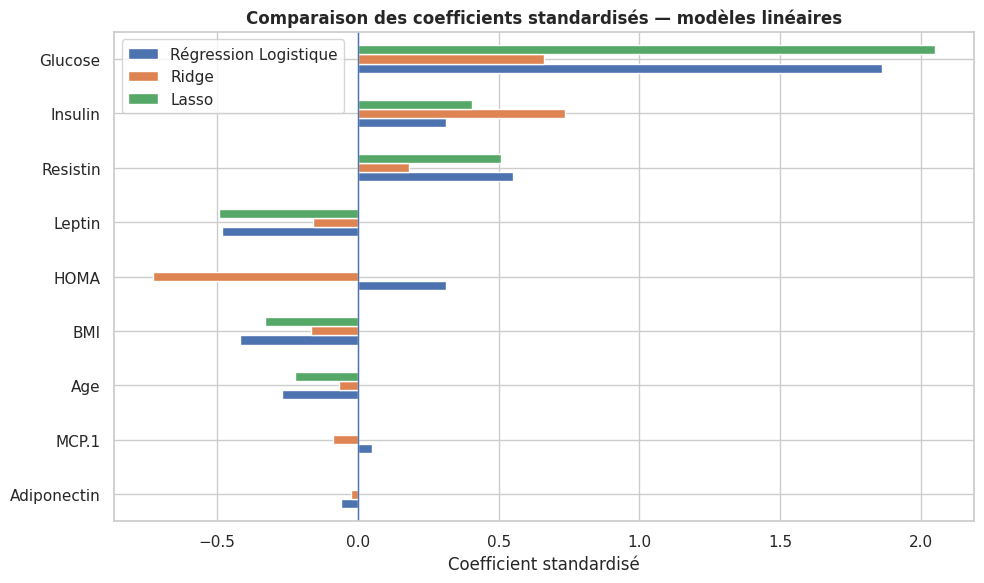

In [25]:
linear_models = ["Régression Logistique", "Ridge", "Lasso"]

coef_tables = {}
for model_name in linear_models:
    if model_name in best_models:
        model_step = best_models[model_name].named_steps["model"]
        if not hasattr(model_step, "coef_"):
            continue

        coef_series = pd.Series(
            extract_coef_vector(model_step),
            index=features
        ).sort_values(key=np.abs, ascending=False)
        coef_tables[model_name] = coef_series

        print(f"\n{model_name}")
        display(coef_series.to_frame("Coefficient standardisé").round(4))

        if model_name == "Lasso":
            selected = coef_series[coef_series != 0]
            eliminated = coef_series[coef_series == 0]
            print(f"Variables retenues par Lasso : {len(selected)}")
            print(f"Variables éliminées par Lasso : {len(eliminated)}")

# Comparaison visuelle globale des coefficients des modèles linéaires.
if coef_tables:
    coef_df = pd.DataFrame(coef_tables).fillna(0)
    coef_df.loc[coef_df.abs().mean(axis=1).sort_values().index].plot(kind="barh", figsize=(10, 6))
    plt.title("Comparaison des coefficients standardisés — modèles linéaires", fontweight="bold")
    plt.xlabel("Coefficient standardisé")
    plt.axvline(0, linewidth=1)
    plt.tight_layout()
    plt.savefig("comparaison_coefficients_modeles_lineaires.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9. Conclusion professionnelle

Cette version compare uniquement les six modèles demandés : Régression Logistique, Naive Bayes, Ridge, Lasso, K-NN et MLP. Elle corrige aussi une erreur conceptuelle importante : `Ridge` n’est plus une deuxième régression logistique L2, mais un `RidgeClassifier`. La baseline `DummyClassifier` est conservée séparément pour vérifier que les modèles apprennent réellement mieux qu’une règle naïve.

La comparaison est plus fiable que la version initiale, car elle utilise un chargement de données portable, des pipelines, une validation croisée répétée et des métriques adaptées au contexte médical. Les scores de test restent toutefois à interpréter comme une indication, pas comme une preuve définitive, car le jeu de test est très petit.

Le choix du meilleur modèle ne doit pas se baser uniquement sur le recall. Un modèle avec un recall très élevé peut être trompeur s’il classe presque toutes les patientes comme `Cancer`. Le meilleur compromis doit donc tenir compte de la sensibilité, de la spécificité, du F1-score, de l’AUC-ROC, des faux négatifs et des faux positifs.

### Limites

- Le dataset est petit : seulement 116 observations.
- Les performances sur le jeu de test peuvent varier fortement selon le split. Avec environ 23 à 24 observations dans le test, l’AUC-ROC, le recall, la spécificité et le F1-score ont une variance élevée : quelques erreurs seulement peuvent changer sensiblement les scores.
- Certaines variables sont corrélées, notamment `Insulin` et `HOMA`.
- La baseline ne sert pas à la sélection finale ; elle sert seulement de repère.
- Les résultats doivent être validés sur un jeu de données plus grand avant toute utilisation réelle.

### Améliorations possibles

- Ajouter des intervalles de confiance pour les métriques.
- Tester plusieurs seuils de décision selon l’objectif clinique.
- Utiliser une validation externe si un autre dataset est disponible.
- Ajouter SHAP ou permutation importance pour expliquer les prédictions.